# PronuncIA  
## Evaluación de pronunciación en japonés mediante Procesamiento del Habla e Inteligencia Artificial

**Materia:** Técnicas de Procesamiento del Habla  
**Proyecto:** PronuncIA  
**Tema:** Evaluación automática de pronunciación en japonés

**Integrantes:**
- Emilce Robles.
- Ian Marini.

PronuncIA es un prototipo que permite analizar grabaciones de voz de una persona pronunciando palabras y frases en japonés. El sistema compara dichas grabaciones con audios de referencia generados mediante Text-to-Speech y calcula un puntaje de similitud acústica.

El proyecto aplica técnicas vistas en la materia, como carga y digitalización de audio, preprocesamiento, visualización de señales, espectrogramas, extracción de características acústicas y comparación de pronunciaciones.

## Objetivo

Desarrollar un sistema simple de evaluación de pronunciación que permita comparar audios grabados por el usuario con audios de referencia en japonés.

El sistema busca:

- Generar audios de referencia mediante Text-to-Speech.
- Cargar audios reales grabados por el usuario en formato `.m4a`.
- Preprocesar las señales de audio.
- Extraer características acústicas como MFCC, RMS, ZCR y centroide espectral.
- Comparar las pronunciaciones usando similitud acústica.
- Clasificar el resultado como excelente, buena, regular o necesita mejorar.

In [1]:
# Instalación de librerías necesarias
# Ejecutar solo si hace falta

!pip install librosa soundfile matplotlib numpy pandas gtts pydub scipy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importación de librerías

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from pydub import AudioSegment
import tempfile

from gtts import gTTS
from IPython.display import Audio, display
from scipy.spatial.distance import euclidean

## Estructura de carpetas

El proyecto utiliza un único notebook y una carpeta principal de audios.

La estructura esperada es:

ISPC-Procesamiento-del-Habla-PronuncIA/
│
├── PronuncIA.ipynb
│
└── audios/
    ├── referencia/
    ├── usuario/
    └── sinteticos/

La carpeta `referencia` contiene audios generados por código mediante Text-to-Speech.  
La carpeta `usuario` contiene las grabaciones reales en formato `.m4a`.  
La carpeta `sinteticos` contiene audios generados artificialmente a partir de las grabaciones del usuario.

In [3]:
# Creación de carpetas

RUTA_REFERENCIA = "audios/referencia"
RUTA_USUARIO = "audios/usuario"
RUTA_SINTETICOS = "audios/sinteticos"

for ruta in [RUTA_REFERENCIA, RUTA_USUARIO, RUTA_SINTETICOS]:
    os.makedirs(ruta, exist_ok=True)

print("Carpetas verificadas correctamente.")

Carpetas verificadas correctamente.


## Vocabulario seleccionado

Se seleccionaron palabras, expresiones y frases cortas en japonés, con el objetivo de evaluar distintos niveles de complejidad en la pronunciación.

El dataset incluye:

- Palabras simples.
- Expresiones de uso cotidiano.
- Frases cortas útiles para una situación de viaje o presentación personal.

In [4]:
# Vocabulario del proyecto

frases_japones = {
    # Palabras simples
    "neko": "ねこ",
    "raamen": "ラーメン",
    "sushi": "すし",
    "mizu": "みず",
    "densha": "でんしゃ",
    
    # Expresiones
    "arigatou": "ありがとう",
    "konnichiwa": "こんにちは",
    "ohayou": "おはよう",
    "sayounara": "さようなら",
    "sumimasen": "すみません",
    
    # Frases cortas
    "ohayou_gozaimasu": "おはようございます",
    "arigatou_gozaimasu": "ありがとうございます",
    "sumimasen_eki_wa_doko_desu_ka": "すみません 駅はどこですか",
    "watashi_wa_emi_desu": "わたしはエミです",
    "raamen_ga_suki_desu": "ラーメンが好きです"
}

metadata_vocabulario = pd.DataFrame({
    "id": frases_japones.keys(),
    "texto_japones": frases_japones.values()
})

metadata_vocabulario

,id,texto_japones
0,neko,ねこ
1,raamen,ラーメン
2,sushi,すし
3,mizu,みず
4,densha,でんしゃ
5,arigatou,ありがとう
6,konnichiwa,こんにちは
7,ohayou,おはよう
8,sayounara,さようなら
9,sumimasen,すみません


## Generación de audios de referencia

Para obtener una pronunciación base, se generan audios de referencia utilizando Text-to-Speech en japonés.

Estos audios se guardan en la carpeta `audios/referencia/` y serán utilizados para comparar las grabaciones del usuario.

In [5]:
# Generar audios de referencia con gTTS

for nombre, texto in frases_japones.items():
    output_path = os.path.join(RUTA_REFERENCIA, f"{nombre}_ref.mp3")
    
    if not os.path.exists(output_path):
        tts = gTTS(text=texto, lang="ja")
        tts.save(output_path)
        print(f"Generado: {output_path}")
    else:
        print(f"Ya existe: {output_path}")

Ya existe: audios/referencia\neko_ref.mp3
Ya existe: audios/referencia\raamen_ref.mp3
Ya existe: audios/referencia\sushi_ref.mp3
Ya existe: audios/referencia\mizu_ref.mp3
Ya existe: audios/referencia\densha_ref.mp3
Ya existe: audios/referencia\arigatou_ref.mp3
Ya existe: audios/referencia\konnichiwa_ref.mp3
Ya existe: audios/referencia\ohayou_ref.mp3
Ya existe: audios/referencia\sayounara_ref.mp3
Ya existe: audios/referencia\sumimasen_ref.mp3
Ya existe: audios/referencia\ohayou_gozaimasu_ref.mp3
Ya existe: audios/referencia\arigatou_gozaimasu_ref.mp3
Ya existe: audios/referencia\sumimasen_eki_wa_doko_desu_ka_ref.mp3
Ya existe: audios/referencia\watashi_wa_emi_desu_ref.mp3
Ya existe: audios/referencia\raamen_ga_suki_desu_ref.mp3


## Audios del usuario

Los audios del usuario deben estar ubicados en la carpeta `audios/usuario/`.

Cada audio representa un intento de pronunciación. Por ejemplo:

- `neko_01.m4a`
- `neko_02.m4a`
- `raamen_01.m4a`
- `raamen_02.m4a`

La idea es que el usuario grabe su pronunciación real, no una versión perfecta. Luego el sistema calcula el nivel de similitud con la referencia.

In [6]:
# Listar audios cargados por el usuario

audios_usuario = [
    archivo for archivo in os.listdir(RUTA_USUARIO)
    if archivo.lower().endswith((".m4a", ".mp3", ".wav", ".mp4"))
]

print(f"Cantidad de audios de usuario encontrados: {len(audios_usuario)}")
audios_usuario[:10]

Cantidad de audios de usuario encontrados: 42


['arigatou_01.mp4',
 'arigatou_02.mp4',
 'arigatou_03.mp4',
 'arigatou_gozaimasu_01.mp4',
 'arigatou_gozaimasu_02.mp4',
 'arigatou_gozaimasu_03.mp4',
 'densha_01.mp4',
 'densha_02.mp4',
 'densha_03.mp4',
 'konnichiwa_01.mp4']

## Carga de audio

Se define una función para cargar audios utilizando `librosa`.  
Todos los audios se convierten a una frecuencia de muestreo uniforme de 16000 Hz para facilitar la comparación.

In [7]:
from pydub import AudioSegment
import tempfile

def cargar_audio(ruta_audio, sr=16000):
    """
    Carga archivos de audio.
    Si son mp4 o m4a los convierte temporalmente a wav.
    """
    
    extension = os.path.splitext(ruta_audio)[1].lower()

    if extension in [".mp4", ".m4a"]:
        audio = AudioSegment.from_file(ruta_audio)

        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_wav:
            temp_path = temp_wav.name

        audio.export(temp_path, format="wav")

        y, sr = librosa.load(temp_path, sr=sr, mono=True)

        os.remove(temp_path)

        return y, sr

    y, sr = librosa.load(ruta_audio, sr=sr, mono=True)

    return y, sr

## Visualización de una señal de audio

Se carga un audio de referencia para observar su forma de onda. Esto permite analizar la amplitud de la señal en función del tiempo.

In [8]:
# Audio de ejemplo

audio_ejemplo = os.path.join(RUTA_REFERENCIA, "neko_ref.mp3")

y, sr = cargar_audio(audio_ejemplo)

print("Frecuencia de muestreo:", sr)
print("Duración:", round(librosa.get_duration(y=y, sr=sr), 2), "segundos")

display(Audio(y, rate=sr))

Frecuencia de muestreo: 16000
Duración: 0.84 segundos


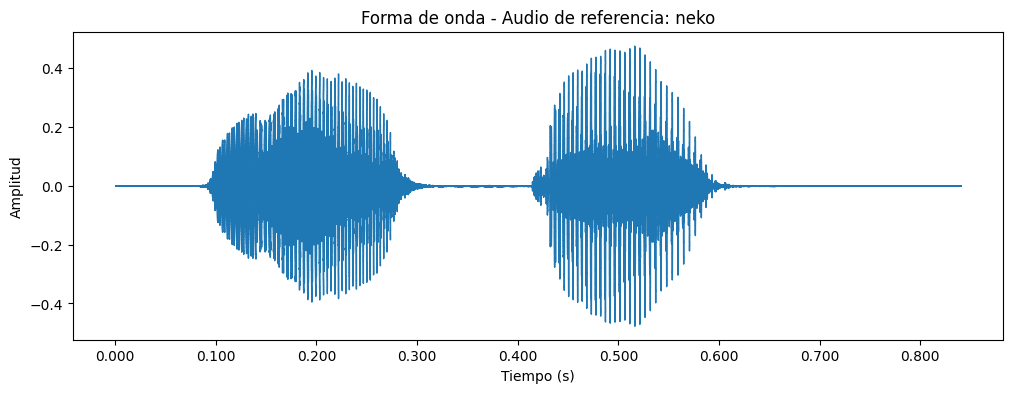

In [9]:
# Forma de onda

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Forma de onda - Audio de referencia: neko")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

## Espectrograma

El espectrograma permite visualizar cómo cambia el contenido frecuencial del audio a lo largo del tiempo.  
Es útil para observar patrones acústicos propios de cada palabra o frase pronunciada.

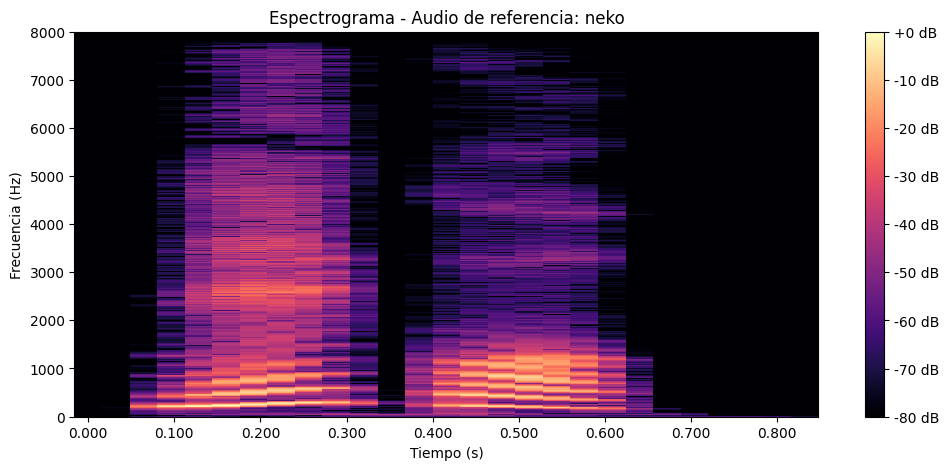

In [10]:
# Espectrograma

D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma - Audio de referencia: neko")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.show()

## Extracción de características acústicas

Se extraen características de audio utilizadas comúnmente en procesamiento del habla:

- **MFCC:** coeficientes cepstrales en frecuencia Mel, relacionados con la percepción humana del sonido.
- **RMS:** energía de la señal.
- **ZCR:** tasa de cruces por cero.
- **Centroide espectral:** indica el centro de masa del espectro.

In [11]:
def extraer_features(ruta_audio, sr=16000):
    """
    Extrae características acústicas básicas de un audio.
    """
    y, sr = cargar_audio(ruta_audio, sr=sr)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
    features = {
        "duracion": librosa.get_duration(y=y, sr=sr),
        "mfcc_mean": np.mean(mfcc),
        "mfcc_std": np.std(mfcc),
        "rms_mean": np.mean(rms),
        "zcr_mean": np.mean(zcr),
        "centroid_mean": np.mean(centroid)
    }
    
    return features

In [12]:
# Probar extracción de características

features_neko = extraer_features(audio_ejemplo)
features_neko

{'duracion': 0.84,
 'mfcc_mean': -27.946053,
 'mfcc_std': 120.7051,
 'rms_mean': 0.068546854,
 'zcr_mean': 0.07362196180555555,
 'centroid_mean': 1361.9610816436223}

## Construcción del dataset de características

En esta etapa se recorren los audios de referencia y los audios del usuario para extraer características acústicas.  
Luego se almacena la información en un DataFrame para su análisis exploratorio.

In [13]:
def obtener_id_desde_usuario(nombre_archivo):
    """
    Extrae el ID base desde un archivo de usuario.
    Ejemplo:
    neko_01.m4a -> neko
    arigatou_gozaimasu_02.m4a -> arigatou_gozaimasu
    """
    nombre = os.path.splitext(nombre_archivo)[0]
    partes = nombre.split("_")
    
    if partes[-1].isdigit():
        return "_".join(partes[:-1])
    
    return nombre

In [14]:
registros = []

# Audios de referencia
for id_frase in frases_japones.keys():
    ruta = os.path.join(RUTA_REFERENCIA, f"{id_frase}_ref.mp3")
    
    if os.path.exists(ruta):
        features = extraer_features(ruta)
        features["archivo"] = f"{id_frase}_ref.mp3"
        features["id_frase"] = id_frase
        features["tipo"] = "referencia"
        registros.append(features)

# Audios del usuario
for archivo in audios_usuario:
    ruta = os.path.join(RUTA_USUARIO, archivo)
    id_frase = obtener_id_desde_usuario(archivo)
    
    features = extraer_features(ruta)
    features["archivo"] = archivo
    features["id_frase"] = id_frase
    features["tipo"] = "usuario"
    registros.append(features)

df_features = pd.DataFrame(registros)
df_features.head()

,duracion,mfcc_mean,mfcc_std,rms_mean,zcr_mean,centroid_mean,archivo,id_frase,tipo
0,0.840,-27.946053,120.705101,0.068547,0.073622,1361.961082,neko_ref.mp3,neko,referencia
1,0.984,-24.623425,103.484726,0.102327,0.072297,1341.742121,raamen_ref.mp3,raamen,referencia
2,0.888,-29.422457,120.016258,0.031973,0.313424,3447.127201,sushi_ref.mp3,sushi,referencia
3,0.840,-27.211376,114.529640,0.064268,0.084328,1665.642465,mizu_ref.mp3,mizu,referencia
4,0.960,-26.005402,105.779327,0.070180,0.166882,2094.689449,densha_ref.mp3,densha,referencia


In [15]:
# Vista general del dataset

df_features

,duracion,mfcc_mean,mfcc_std,rms_mean,zcr_mean,centroid_mean,archivo,id_frase,tipo
0,0.840,-27.946053,120.705101,0.068547,0.073622,1361.961082,neko_ref.mp3,neko,referencia
1,0.984,-24.623425,103.484726,0.102327,0.072297,1341.742121,raamen_ref.mp3,raamen,referencia
2,0.888,-29.422457,120.016258,0.031973,0.313424,3447.127201,sushi_ref.mp3,sushi,referencia
3,0.840,-27.211376,114.529640,0.064268,0.084328,1665.642465,mizu_ref.mp3,mizu,referencia
4,0.960,-26.005402,105.779327,0.070180,0.166882,2094.689449,densha_ref.mp3,densha,referencia
5,1.152,-23.843887,104.469002,0.082091,0.071157,1387.743054,arigatou_ref.mp3,arigatou,referencia
6,1.272,-23.376120,97.180542,0.109117,0.108521,1646.860815,konnichiwa_ref.mp3,konnichiwa,referencia
7,1.056,-25.065750,102.331200,0.102480,0.089758,1406.594118,ohayou_ref.mp3,ohayou,referencia
8,1.296,-24.389059,91.832649,0.112543,0.124786,1832.904718,sayounara_ref.mp3,sayounara,referencia
9,1.224,-25.706503,99.277008,0.085649,0.158454,2024.454333,sumimasen_ref.mp3,sumimasen,referencia


## Análisis exploratorio de características

Se comparan algunas características acústicas entre los audios de referencia y los audios del usuario.

In [16]:
# Cantidad de audios por tipo

df_features["tipo"].value_counts()

tipo
usuario       42
referencia    15
Name: count, dtype: int64

In [17]:
# Duración promedio por tipo

df_features.groupby("tipo")["duracion"].mean()

tipo
referencia    1.345600
usuario       1.723429
Name: duracion, dtype: float64

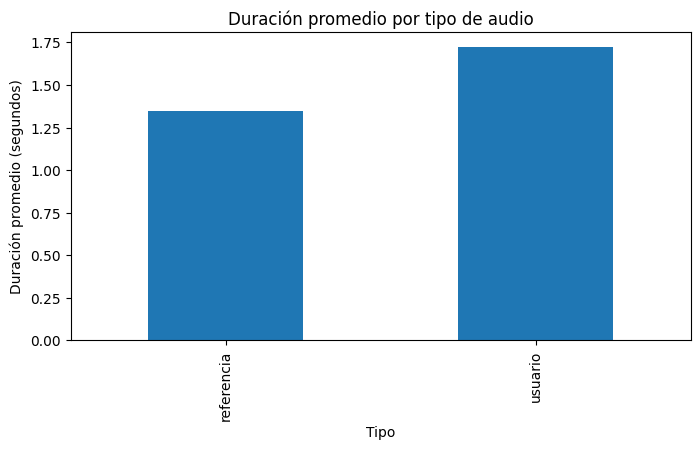

In [18]:
# Comparación de duración

plt.figure(figsize=(8, 4))
df_features.groupby("tipo")["duracion"].mean().plot(kind="bar")
plt.title("Duración promedio por tipo de audio")
plt.ylabel("Duración promedio (segundos)")
plt.xlabel("Tipo")
plt.show()

## Visualización de MFCC

Los MFCC permiten representar características relevantes del habla.  
A continuación se visualizan los MFCC de un audio de referencia.

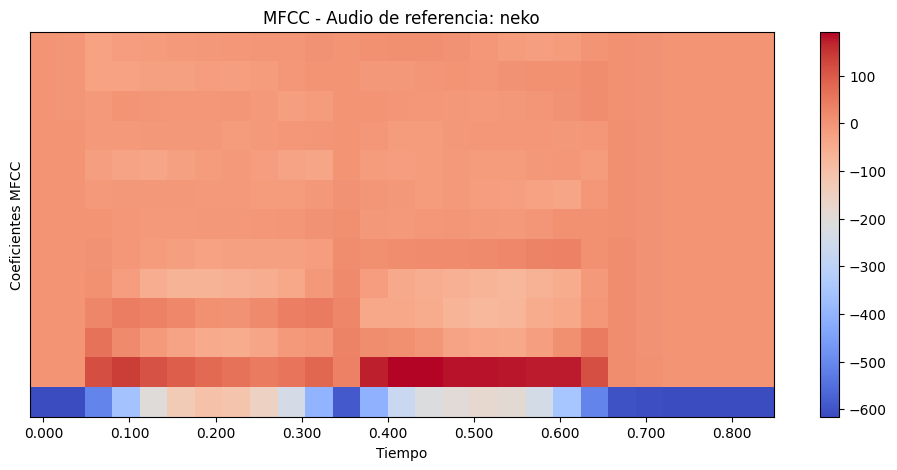

In [19]:
# MFCC de un audio de referencia

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12, 5))
librosa.display.specshow(mfcc, sr=sr, x_axis="time")
plt.colorbar()
plt.title("MFCC - Audio de referencia: neko")
plt.xlabel("Tiempo")
plt.ylabel("Coeficientes MFCC")
plt.show()

## Generación de audios sintéticos

Para ampliar el dataset, se aplican técnicas simples de data augmentation sobre los audios del usuario.

Se generan variaciones como:

- Audio más rápido.
- Audio más lento.
- Cambio de tono hacia arriba.
- Cambio de tono hacia abajo.
- Agregado de ruido leve.

Estos audios permiten observar cómo pequeñas modificaciones afectan las características acústicas.

In [20]:
def generar_audios_sinteticos(ruta_audio, nombre_base, output_dir=RUTA_SINTETICOS, sr=16000):
    """
    Genera variaciones sintéticas de un audio.
    """
    y, sr = cargar_audio(ruta_audio, sr=sr)
    
    # Más rápido
    y_fast = librosa.effects.time_stretch(y, rate=1.15)
    sf.write(os.path.join(output_dir, f"{nombre_base}_fast.wav"), y_fast, sr)
    
    # Más lento
    y_slow = librosa.effects.time_stretch(y, rate=0.85)
    sf.write(os.path.join(output_dir, f"{nombre_base}_slow.wav"), y_slow, sr)
    
    # Tono más alto
    y_pitch_up = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
    sf.write(os.path.join(output_dir, f"{nombre_base}_pitch_up.wav"), y_pitch_up, sr)
    
    # Tono más bajo
    y_pitch_down = librosa.effects.pitch_shift(y, sr=sr, n_steps=-2)
    sf.write(os.path.join(output_dir, f"{nombre_base}_pitch_down.wav"), y_pitch_down, sr)
    
    # Ruido leve
    ruido = np.random.normal(0, 0.005, y.shape)
    y_noise = y + ruido
    sf.write(os.path.join(output_dir, f"{nombre_base}_noise.wav"), y_noise, sr)

In [21]:
# Generar audios sintéticos a partir de los audios del usuario

for archivo in audios_usuario:
    ruta = os.path.join(RUTA_USUARIO, archivo)
    nombre_base = os.path.splitext(archivo)[0]
    generar_audios_sinteticos(ruta, nombre_base)

print("Audios sintéticos generados correctamente.")

Audios sintéticos generados correctamente.


In [22]:
# Listar audios sintéticos generados

audios_sinteticos = [
    archivo for archivo in os.listdir(RUTA_SINTETICOS)
    if archivo.lower().endswith(".wav")
]

print(f"Cantidad de audios sintéticos generados: {len(audios_sinteticos)}")
audios_sinteticos[:10]

Cantidad de audios sintéticos generados: 210


['arigatou_01_fast.wav',
 'arigatou_01_noise.wav',
 'arigatou_01_pitch_down.wav',
 'arigatou_01_pitch_up.wav',
 'arigatou_01_slow.wav',
 'arigatou_02_fast.wav',
 'arigatou_02_noise.wav',
 'arigatou_02_pitch_down.wav',
 'arigatou_02_pitch_up.wav',
 'arigatou_02_slow.wav']

## Comparación de pronunciación

Para comparar una pronunciación del usuario con la referencia, se extraen los MFCC de ambos audios.

Luego se calcula una distancia entre los vectores promedio de MFCC.  
A menor distancia, mayor similitud acústica.

In [23]:
def vector_mfcc_promedio(ruta_audio, sr=16000):
    """
    Obtiene el vector promedio de MFCC de un audio.
    """
    y, sr = cargar_audio(ruta_audio, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)

In [24]:
def calcular_similitud(ruta_referencia, ruta_usuario):
    """
    Calcula similitud entre dos audios usando distancia euclidiana
    entre vectores promedio de MFCC.
    """
    vec_ref = vector_mfcc_promedio(ruta_referencia)
    vec_user = vector_mfcc_promedio(ruta_usuario)
    
    distancia = euclidean(vec_ref, vec_user)
    
    # Conversión simple de distancia a score entre 0 y 100
    score = 100 / (1 + distancia / 100)
    
    return round(score, 2), round(distancia, 2)

In [25]:
def clasificar_pronunciacion(score):
    """
    Clasifica la pronunciación según el score de similitud.
    """
    if score >= 85:
        return "Excelente"
    elif score >= 70:
        return "Buena"
    elif score >= 55:
        return "Regular"
    else:
        return "Necesita mejorar"

## Evaluación de los audios del usuario

Se compara cada grabación del usuario con su audio de referencia correspondiente.

Por ejemplo:

- `neko_01.m4a` se compara con `neko_ref.mp3`
- `raamen_02.m4a` se compara con `raamen_ref.mp3`

In [26]:
resultados = []

for archivo in audios_usuario:
    id_frase = obtener_id_desde_usuario(archivo)
    
    ruta_usuario = os.path.join(RUTA_USUARIO, archivo)
    ruta_ref = os.path.join(RUTA_REFERENCIA, f"{id_frase}_ref.mp3")
    
    if os.path.exists(ruta_ref):
        score, distancia = calcular_similitud(ruta_ref, ruta_usuario)
        clasificacion = clasificar_pronunciacion(score)
        
        resultados.append({
            "archivo_usuario": archivo,
            "id_frase": id_frase,
            "texto_japones": frases_japones.get(id_frase, ""),
            "score_similitud": score,
            "distancia_mfcc": distancia,
            "clasificacion": clasificacion
        })
    else:
        print(f"No se encontró referencia para: {archivo}")

df_resultados = pd.DataFrame(resultados)
df_resultados

No se encontró referencia para: ramen_ga_suki_desu_01.mp4


,archivo_usuario,id_frase,texto_japones,score_similitud,distancia_mfcc,clasificacion
0,arigatou_01.mp4,arigatou,ありがとう,34.66,188.54,Necesita mejorar
1,arigatou_02.mp4,arigatou,ありがとう,33.76,196.17,Necesita mejorar
2,arigatou_03.mp4,arigatou,ありがとう,33.87,195.21,Necesita mejorar
3,arigatou_gozaimasu_01.mp4,arigatou_gozaimasu,ありがとうございます,41.86,138.92,Necesita mejorar
4,arigatou_gozaimasu_02.mp4,arigatou_gozaimasu,ありがとうございます,38.01,163.08,Necesita mejorar
5,arigatou_gozaimasu_03.mp4,arigatou_gozaimasu,ありがとうございます,40.09,149.46,Necesita mejorar
6,densha_01.mp4,densha,でんしゃ,29.87,234.76,Necesita mejorar
7,densha_02.mp4,densha,でんしゃ,38.86,157.36,Necesita mejorar
8,densha_03.mp4,densha,でんしゃ,28.40,252.11,Necesita mejorar
9,konnichiwa_01.mp4,konnichiwa,こんにちは,32.31,209.49,Necesita mejorar


## Resultados generales

Se analizan los puntajes obtenidos por las grabaciones del usuario.

In [27]:
# Promedio de similitud

df_resultados["score_similitud"].mean()

36.87682926829268

In [28]:
# Resultados ordenados por score

df_resultados.sort_values(by="score_similitud", ascending=False)

,archivo_usuario,id_frase,texto_japones,score_similitud,distancia_mfcc,clasificacion
11,konnichiwa_03.mp4,konnichiwa,こんにちは,48.00,108.33,Necesita mejorar
37,sushi_03.mp4,sushi,すし,45.25,121.00,Necesita mejorar
40,watashi_wa_emi_desu_03.mp4,watashi_wa_emi_desu,わたしはエミです,44.70,123.72,Necesita mejorar
38,watashi_wa_emi_desu_01.mp4,watashi_wa_emi_desu,わたしはエミです,44.12,126.68,Necesita mejorar
27,raamen_ga_suki_desu_02.mp4,raamen_ga_suki_desu,ラーメンが好きです,43.49,129.92,Necesita mejorar
36,sushi_02.mp4,sushi,すし,42.98,132.68,Necesita mejorar
22,ohayou_gozaimasu_02.mp4,ohayou_gozaimasu,おはようございます,42.06,137.78,Necesita mejorar
3,arigatou_gozaimasu_01.mp4,arigatou_gozaimasu,ありがとうございます,41.86,138.92,Necesita mejorar
39,watashi_wa_emi_desu_02.mp4,watashi_wa_emi_desu,わたしはエミです,40.87,144.71,Necesita mejorar
34,sumimasen_eki_wa_doko_desu_ka_01.mp4,sumimasen_eki_wa_doko_desu_ka,すみません 駅はどこですか,40.75,145.42,Necesita mejorar


In [29]:
# Cantidad por clasificación

df_resultados["clasificacion"].value_counts()

clasificacion
Necesita mejorar    41
Name: count, dtype: int64

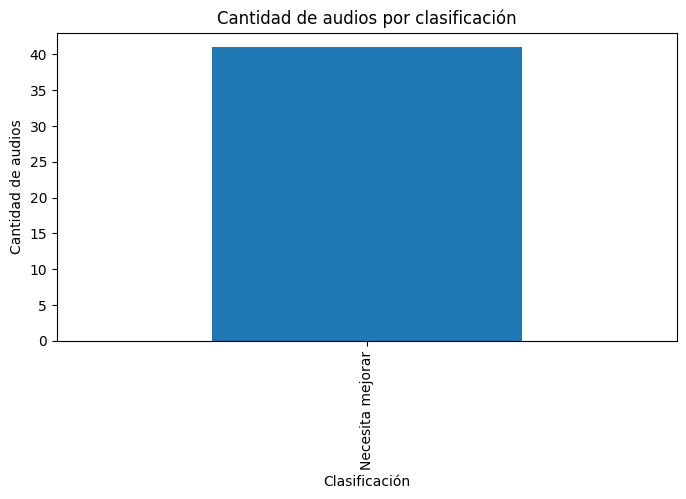

In [30]:
# Gráfico de clasificación

plt.figure(figsize=(8, 4))
df_resultados["clasificacion"].value_counts().plot(kind="bar")
plt.title("Cantidad de audios por clasificación")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de audios")
plt.show()

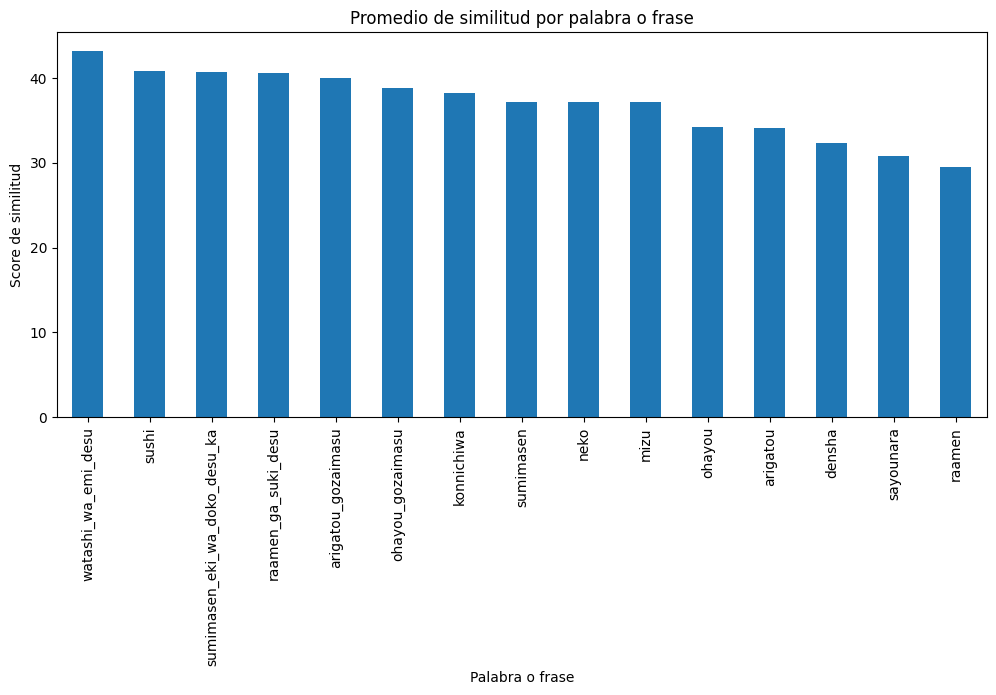

In [31]:
# Promedio de similitud por frase

df_promedio_frase = df_resultados.groupby("id_frase")["score_similitud"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
df_promedio_frase.plot(kind="bar")
plt.title("Promedio de similitud por palabra o frase")
plt.xlabel("Palabra o frase")
plt.ylabel("Score de similitud")
plt.xticks(rotation=90)
plt.show()

## Comparación entre referencia y usuario

A continuación se selecciona un audio del usuario para comparar visualmente su forma de onda con la referencia correspondiente.

In [32]:
# Seleccionar un audio para comparar

archivo_comparacion = audios_usuario[0]

id_frase = obtener_id_desde_usuario(archivo_comparacion)

ruta_usuario = os.path.join(RUTA_USUARIO, archivo_comparacion)
ruta_ref = os.path.join(RUTA_REFERENCIA, f"{id_frase}_ref.mp3")

y_ref, sr_ref = cargar_audio(ruta_ref)
y_user, sr_user = cargar_audio(ruta_usuario)

print("Audio seleccionado:", archivo_comparacion)
print("Texto japonés:", frases_japones.get(id_frase, ""))

display(Audio(y_ref, rate=sr_ref))
display(Audio(y_user, rate=sr_user))

Audio seleccionado: arigatou_01.mp4
Texto japonés: ありがとう


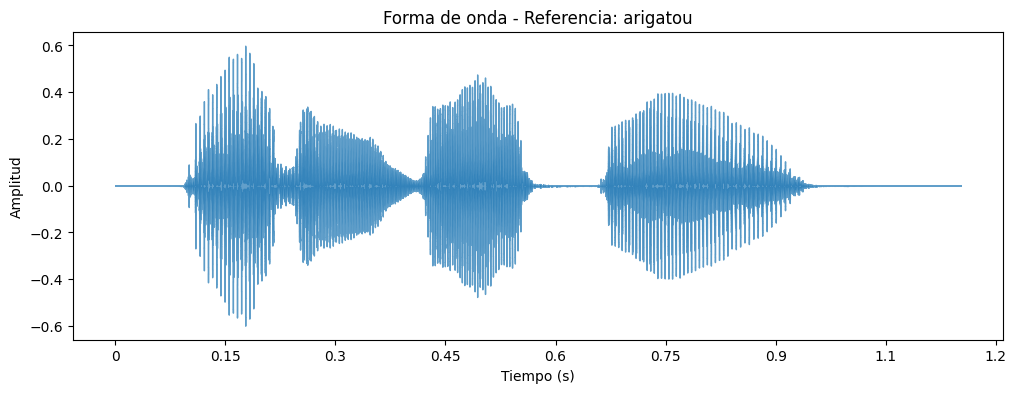

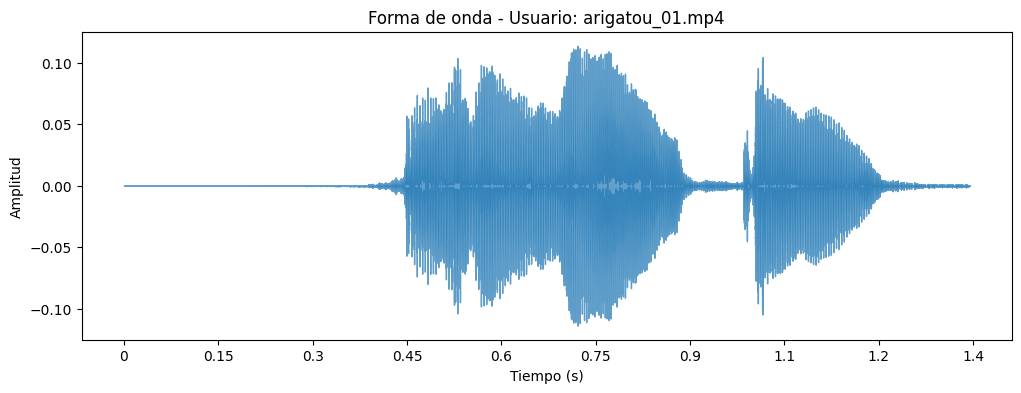

In [33]:
# Comparación de formas de onda

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_ref, sr=sr_ref, alpha=0.7)
plt.title(f"Forma de onda - Referencia: {id_frase}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_user, sr=sr_user, alpha=0.7)
plt.title(f"Forma de onda - Usuario: {archivo_comparacion}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

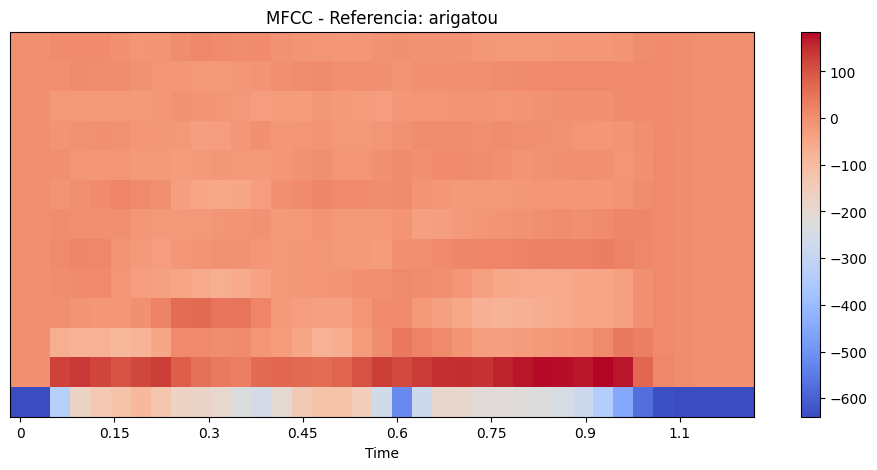

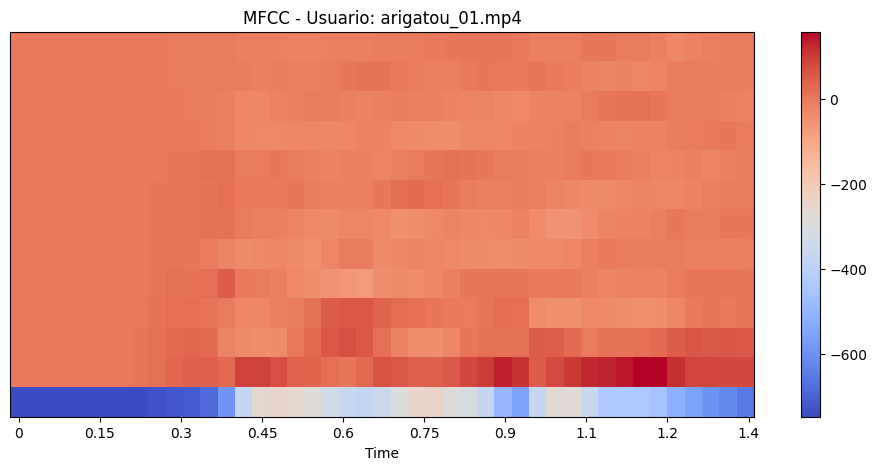

In [34]:
# Comparación de MFCC

mfcc_ref = librosa.feature.mfcc(y=y_ref, sr=sr_ref, n_mfcc=13)
mfcc_user = librosa.feature.mfcc(y=y_user, sr=sr_user, n_mfcc=13)

plt.figure(figsize=(12, 5))
librosa.display.specshow(mfcc_ref, sr=sr_ref, x_axis="time")
plt.colorbar()
plt.title(f"MFCC - Referencia: {id_frase}")
plt.show()

plt.figure(figsize=(12, 5))
librosa.display.specshow(mfcc_user, sr=sr_user, x_axis="time")
plt.colorbar()
plt.title(f"MFCC - Usuario: {archivo_comparacion}")
plt.show()

## Interpretación

El sistema calcula una distancia entre las características MFCC de la pronunciación de referencia y la pronunciación del usuario.

A partir de esa distancia, se obtiene un puntaje de similitud entre 0 y 100.  
Luego, el puntaje se clasifica de la siguiente manera:

- 85 a 100: Excelente
- 70 a 84: Buena
- 55 a 69: Regular
- Menor a 55: Necesita mejorar

Esta clasificación permite obtener una retroalimentación automática sobre la pronunciación.

## Conclusión

En este proyecto se desarrolló un prototipo llamado PronuncIA, orientado a la evaluación automática de pronunciación en japonés.

A partir de audios de referencia generados mediante Text-to-Speech y grabaciones reales del usuario, se aplicaron técnicas de procesamiento del habla para analizar y comparar señales de audio.

El proyecto permitió trabajar con carga y digitalización de audio, visualización de forma de onda, espectrogramas, extracción de características acústicas y cálculo de similitud mediante MFCC.

Los resultados obtenidos permiten clasificar la pronunciación del usuario en distintos niveles de desempeño, brindando una primera aproximación a un sistema inteligente de apoyo al aprendizaje de idiomas.

Como mejora futura, se podría ampliar el dataset con más hablantes, incorporar audios de referencia de hablantes nativos y entrenar modelos de aprendizaje automático supervisado para clasificar automáticamente la calidad de pronunciación.